# Analyse de `MIT ETUDE.xlsx`

Ce notebook charge le fichier Excel, nettoie quelques libellés, affiche un résumé rapide et génère des graphes directement dans les cellules.

In [48]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [49]:
BASE_DIR = Path.cwd()
INPUT_FILE = BASE_DIR / 'MIT ETUDE.xlsx'
OUTPUT_NOTEBOOK_DIR = BASE_DIR / 'output_analyse_notebook'



def normalize_text(value):
    if pd.isna(value):
        return ''
    return str(value).strip()


def parse_months(value):
    if not value:
        return None
    text = str(value).lower().strip()
    match = re.search(r'(\d+)', text)
    return float(match.group(1)) if match else None


def normalize_dataframe(df):
    cleaned = df.copy()

    for column in cleaned.columns:
        cleaned[column] = cleaned[column].map(normalize_text)

    cleaned['Situation'] = cleaned['Situation'].replace({
        'Employée': 'Employé',
        'En recherche': 'Recherche',
    })

    cleaned['Compétences manquantes'] = cleaned['Compétences manquantes'].replace({
        'Technique': 'Tech',
        'Exp technique': 'Tech',
        'Dev': 'Code/Dev',
        'Code': 'Code/Dev',
    })

    cleaned['Difficulté principale'] = cleaned['Difficulté principale'].replace({
        'Exp': 'Expérience',
        'Manque expérience': 'Expérience',
        'Technique': 'Techniques',
        'Tests techniques': 'Techniques',
        'Tests': 'Techniques',
        'Stress entretien': 'Entretien/Stress',
        'Stress': 'Entretien/Stress',
        'Entretien': 'Entretien/Stress',
        'Manque réseau': 'Réseau',
    })

    cleaned['Comment trouvé'] = cleaned['Comment trouvé'].replace({
        'Sites web': 'Sites',
    })

    cleaned['Temps_mois'] = cleaned['Temps pour emploi'].map(parse_months)
    return cleaned

def to_percentages(series):
    counts = series.value_counts()
    return counts / counts.sum() * 100

def save_bar_percent(percentages, title, filename, color, xlabel='', rotation=0, ha='center'):
    fig, ax = plt.subplots(figsize=(8, 4))
    percentages.plot(kind='bar', color=color, edgecolor='black', ax=ax, title=title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Pourcentage (%)')
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_ha(ha)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')
    fig.tight_layout()
    fig.savefig(OUTPUT_NOTEBOOK_DIR / filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_pie_percent(percentages, title, filename, colors):
    fig, ax = plt.subplots(figsize=(6, 6))
    percentages.plot(
        kind='pie', autopct='%1.1f%%', startangle=90, ylabel='',
        colors=colors, title=title, ax=ax
    )
    fig.tight_layout()
    fig.savefig(OUTPUT_NOTEBOOK_DIR / filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_histogram(series, title, filename, bins=6, color='#f4a261'):
    fig, ax = plt.subplots(figsize=(8, 4))
    series.plot(kind='hist', bins=bins, color=color, edgecolor='black', title=title, ax=ax)
    ax.set_xlabel('Mois')
    ax.set_ylabel('Nombre de r?ponses')
    fig.tight_layout()
    fig.savefig(OUTPUT_NOTEBOOK_DIR / filename, dpi=150, bbox_inches='tight')
    plt.close(fig)


In [50]:
df = pd.read_excel(INPUT_FILE)
df = normalize_dataframe(df)

print(f'Nombre de lignes : {len(df)}')
print(f'Nombre de colonnes : {len(df.columns)}')
df.head()

Nombre de lignes : 21
Nombre de colonnes : 13


,Année,Sexe,Situation,Temps pour emploi,Emploi lié ?,Secteur,Compétences utiles,Compétences manquantes,Difficulté principale,Comment trouvé,Amélioration master,Recommande ?,Temps_mois
0,2024,Femme,Employé,3 mois,Oui,Industrie,Gestion projet,Tech,Expérience,LinkedIn,Plus pratique,Oui,3.0
1,2025,Femme,Recherche,+6 mois,-,-,Communication,Tech,Trouver offre,Sites,Stages,Oui,6.0
2,2025,Homme,Employé,2 mois,Oui,IT,Analyse données,Programmation,Compétition,Réseau,Plus IT,Oui,2.0
3,2024,Homme,Employé,4 mois,Oui,Logistique,Organisation,Logiciels,Expérience,LinkedIn,Cas pratiques,Oui,4.0
4,2025,Femme,Stage,1 mois,Oui,Conseil,Soft skills,Tech,Entretien/Stress,École,Coaching,Oui,1.0


In [51]:
resume = pd.Series({
    'Total réponses': len(df),
    'Taux emploi/stage (%)': round(((df['Situation'] == 'Employé') | (df['Situation'] == 'Stage')).mean() * 100, 1),
    'Emploi lié au master (%)': round((df['Emploi lié ?'] == 'Oui').mean() * 100, 1),
    'Temps moyen pour emploi (mois)': round(df['Temps_mois'].mean(), 2),
    'Temps médian pour emploi (mois)': round(df['Temps_mois'].median(), 2),
    'Recommandent le master (%)': round((df['Recommande ?'] == 'Oui').mean() * 100, 1),
})

resume.to_frame('Valeur')

,Valeur
Total réponses,21.00
Taux emploi/stage (%),71.40
Emploi lié au master (%),76.20
Temps moyen pour emploi (mois),3.33
Temps médian pour emploi (mois),3.00
Recommandent le master (%),81.00


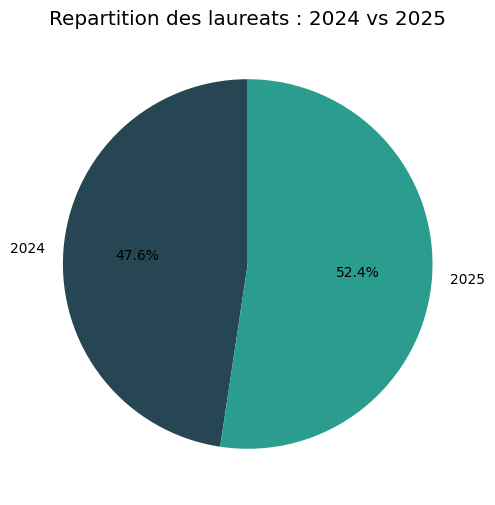

In [54]:
annee_col = next(col for col in df.columns if str(col).startswith('Ann'))
annee_pct = to_percentages(df[annee_col]).sort_index()

ax = annee_pct.plot(
    kind='pie', figsize=(6, 6), autopct='%1.1f%%', startangle=90,
    colors=['#264653', '#2a9d8f'], ylabel='', title='Repartition des laureats : 2024 vs 2025'
)
plt.show()

## Graphes

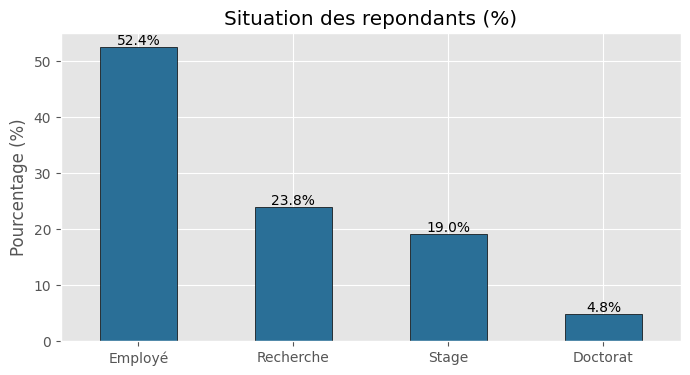

In [55]:
situation_pct = to_percentages(df['Situation'])

ax = situation_pct.plot(
    kind='bar', figsize=(8, 4), color='#2a6f97', edgecolor='black', title='Situation des repondants (%)'
)
ax.set_xlabel('')
ax.set_ylabel('Pourcentage (%)')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

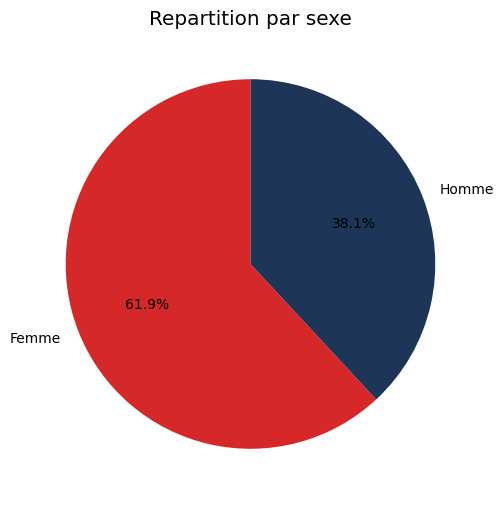

In [56]:
sexe_pct = to_percentages(df['Sexe'])

ax = sexe_pct.plot(
    kind='pie', figsize=(6, 6), autopct='%1.1f%%', startangle=90,
    colors=['#d62828', '#1d3557'], ylabel='', title='Repartition par sexe'
)
plt.show()

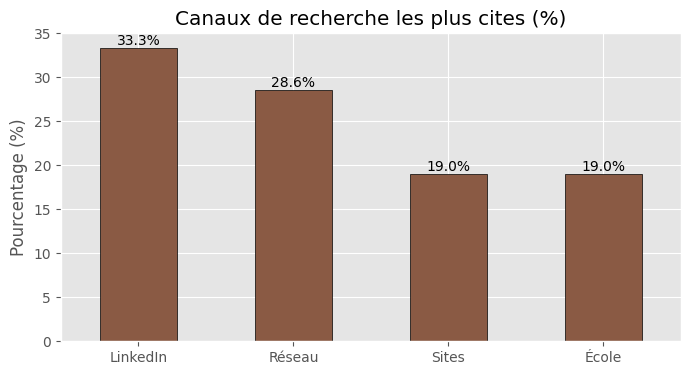

In [57]:
canaux_col = next(col for col in df.columns if str(col).startswith('Comment'))
canaux_pct = to_percentages(df[canaux_col])

ax = canaux_pct.plot(
    kind='bar', figsize=(8, 4), color='#8a5a44', edgecolor='black', title='Canaux de recherche les plus cites (%)'
)
ax.set_xlabel('')
ax.set_ylabel('Pourcentage (%)')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

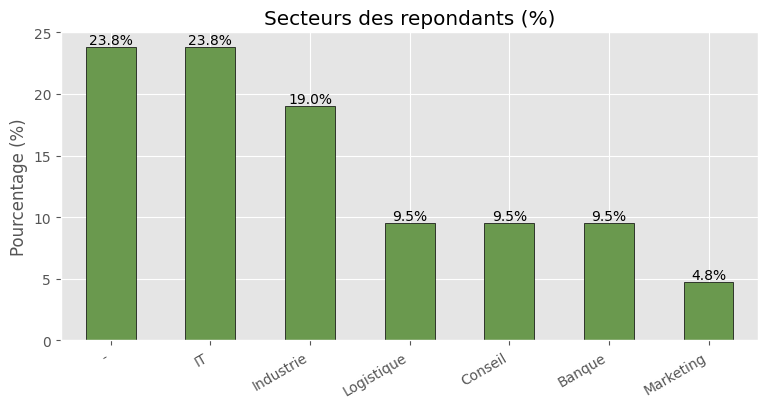

In [58]:
secteur_pct = to_percentages(df['Secteur'])

ax = secteur_pct.plot(
    kind='bar', figsize=(9, 4), color='#6a994e', edgecolor='black', title='Secteurs des repondants (%)'
)
ax.set_xlabel('')
ax.set_ylabel('Pourcentage (%)')
plt.xticks(rotation=30, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

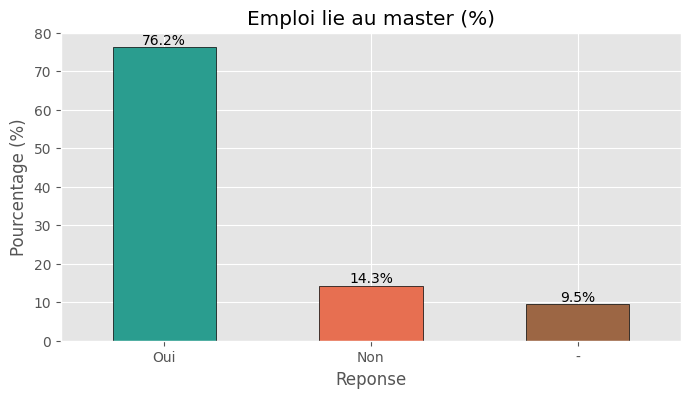

In [59]:
emploi_col = next(col for col in df.columns if str(col).startswith('Emploi'))
emploi_pct = to_percentages(df[emploi_col])

ax = emploi_pct.plot(
    kind='bar', figsize=(8, 4), color=['#2a9d8f', '#e76f51', '#9c6644'], edgecolor='black',
    title='Emploi lie au master (%)'
)
ax.set_xlabel('Reponse')
ax.set_ylabel('Pourcentage (%)')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

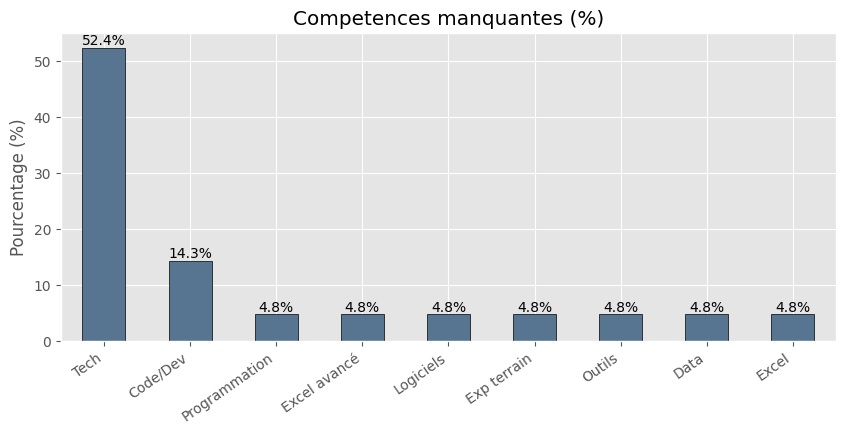

In [60]:
competences_col = next(col for col in df.columns if 'manquantes' in str(col))
competences_pct = to_percentages(df[competences_col])

ax = competences_pct.plot(
    kind='bar', figsize=(10, 4), color='#577590', edgecolor='black', title='Competences manquantes (%)'
)
ax.set_xlabel('')
ax.set_ylabel('Pourcentage (%)')
plt.xticks(rotation=35, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

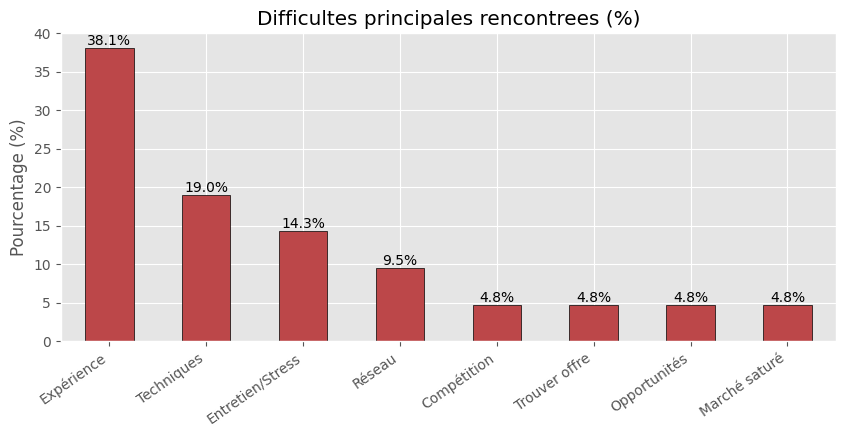

In [61]:
difficulte_col = next(col for col in df.columns if str(col).startswith('Difficult'))
difficulte_pct = to_percentages(df[difficulte_col])

ax = difficulte_pct.plot(
    kind='bar', figsize=(10, 4), color='#bc4749', edgecolor='black', title='Difficultes principales rencontrees (%)'
)
ax.set_xlabel('')
ax.set_ylabel('Pourcentage (%)')
plt.xticks(rotation=35, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

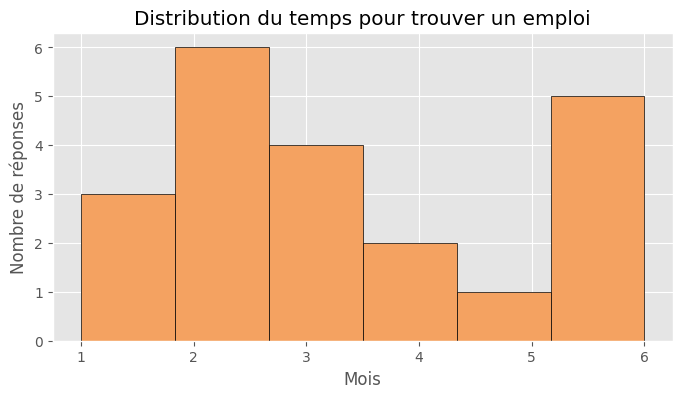

In [62]:
ax = df['Temps_mois'].plot(
    kind='hist', bins=6, figsize=(8, 4), color='#f4a261', edgecolor='black', title='Distribution du temps pour trouver un emploi'
)
ax.set_xlabel('Mois')
ax.set_ylabel('Nombre de réponses')
plt.show()

In [ ]:
annee_col = next(col for col in df.columns if str(col).startswith('Ann'))
tableau_croise = pd.crosstab(df[annee_col], df['Situation'])
tableau_croise

## Export des outputs

Cette section enregistre les graphes et les tableaux du notebook dans un dossier s?par?.

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

OUTPUT_NOTEBOOK_DIR = Path.cwd() / "output_analyse_notebook"
OUTPUT_NOTEBOOK_DIR.mkdir(exist_ok=True)

def find_col_start(prefix):
    prefix = prefix.lower()
    for col in df.columns:
        if str(col).lower().startswith(prefix):
            return col
    raise KeyError(f"Colonne introuvable pour le préfixe : {prefix}")

def find_col_contains(text):
    text = text.lower()
    for col in df.columns:
        if text in str(col).lower():
            return col
    raise KeyError(f"Colonne introuvable contenant : {text}")

def to_percentages(series):
    counts = series.value_counts()
    return counts / counts.sum() * 100

def save_bar_percent(percentages, title, filename, color, xlabel="", rotation=0, ha="center"):
    fig, ax = plt.subplots(figsize=(8, 4))
    percentages.plot(kind="bar", color=color, edgecolor="black", ax=ax, title=title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pourcentage (%)")
    ax.tick_params(axis="x", rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_ha(ha)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%")
    fig.tight_layout()
    fig.savefig(OUTPUT_NOTEBOOK_DIR / filename, dpi=150, bbox_inches="tight")
    plt.close(fig)

def save_pie_percent(percentages, title, filename, colors):
    fig, ax = plt.subplots(figsize=(6, 6))
    percentages.plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=90,
        ylabel="",
        colors=colors,
        title=title,
        ax=ax,
    )
    fig.tight_layout()
    fig.savefig(OUTPUT_NOTEBOOK_DIR / filename, dpi=150, bbox_inches="tight")
    plt.close(fig)

def save_histogram(series, title, filename, bins=6, color="#f4a261"):
    fig, ax = plt.subplots(figsize=(8, 4))
    series.plot(kind="hist", bins=bins, color=color, edgecolor="black", ax=ax, title=title)
    ax.set_xlabel("Mois")
    ax.set_ylabel("Nombre de réponses")
    fig.tight_layout()
    fig.savefig(OUTPUT_NOTEBOOK_DIR / filename, dpi=150, bbox_inches="tight")
    plt.close(fig)

annee_col = find_col_start("ann")
comment_col = find_col_start("comment")
emploi_col = find_col_start("emploi")
competences_col = find_col_contains("manqu")
difficulte_col = find_col_start("difficult")

resume_df = pd.Series({
    "Total réponses": len(df),
    "Taux emploi/stage (%)": round(((df["Situation"] == "Employé") | (df["Situation"] == "Stage")).mean() * 100, 1),
    "Emploi lié au master (%)": round((df[emploi_col] == "Oui").mean() * 100, 1),
    "Temps moyen pour emploi (mois)": round(df["Temps_mois"].mean(), 2),
    "Temps médian pour emploi (mois)": round(df["Temps_mois"].median(), 2),
    "Recommandent le master (%)": round((df["Recommande ?"] == "Oui").mean() * 100, 1),
}).to_frame("Valeur")

tableau_croise = pd.crosstab(df[annee_col], df["Situation"])

resume_txt = OUTPUT_NOTEBOOK_DIR / "resume_analyse.txt"
tableau_txt = OUTPUT_NOTEBOOK_DIR / "tableau_croise_annee_situation.txt"
donnees_txt = OUTPUT_NOTEBOOK_DIR / "donnees_nettoyees_notebook.txt"

resume_txt.write_text(resume_df.to_string(), encoding="utf-8")
tableau_txt.write_text(tableau_croise.to_string(), encoding="utf-8")
donnees_txt.write_text(df.to_string(index=False), encoding="utf-8")

save_pie_percent(
    to_percentages(df[annee_col]).sort_index(),
    "Repartition des laureats : 2024 vs 2025",
    "camembert_annee.png",
    ["#264653", "#2a9d8f"],
)

save_bar_percent(
    to_percentages(df["Situation"]),
    "Situation des repondants (%)",
    "graphe_situation.png",
    "#2a6f97",
)

save_pie_percent(
    to_percentages(df["Sexe"]),
    "Repartition par sexe",
    "graphe_sexe.png",
    ["#d62828", "#1d3557"],
)

save_bar_percent(
    to_percentages(df[comment_col]),
    "Canaux de recherche les plus cites (%)",
    "graphe_canaux.png",
    "#8a5a44",
)

save_bar_percent(
    to_percentages(df["Secteur"]),
    "Secteurs des repondants (%)",
    "graphe_secteur.png",
    "#6a994e",
    rotation=30,
    ha="right",
)

save_bar_percent(
    to_percentages(df[emploi_col]),
    "Emploi lie au master (%)",
    "graphe_emploi_lie.png",
    ["#2a9d8f", "#e76f51", "#9c6644"],
    xlabel="Reponse",
)

save_bar_percent(
    to_percentages(df[competences_col]),
    "Competences manquantes (%)",
    "graphe_competences.png",
    "#577590",
    rotation=35,
    ha="right",
)

save_bar_percent(
    to_percentages(df[difficulte_col]),
    "Difficultes principales rencontrees (%)",
    "graphe_difficultes.png",
    "#bc4749",
    rotation=35,
    ha="right",
)

save_histogram(
    df["Temps_mois"],
    "Distribution du temps pour trouver un emploi",
    "graphe_temps.png",
)

print(f"Outputs enregistres dans : {OUTPUT_NOTEBOOK_DIR}")
